In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.ticker as mticker

# TEMPO

Os gráficos deste capítulo mostram mudanças ao longo do tempo. É muito provável que seus leitores estejam familiarizados com recursos visuais como gráficos de linhas, de áreas e de áreas empilhadas. No entanto, outros tipos — como gráficos de dispersão conectados e gráficos cíclicos — podem exigir mais legendas e anotações para que o leitor consiga interpretá-los adequadamente.

Muitas das representações visuais deste capítulo são variações de gráficos de linhas ou de áreas. Algumas permitem incluir mais dados na página do que o habitual, enquanto outras possibilitam combinar variações ao longo do tempo com outras formas de visualizar os dados. Com gráficos de horizonte (*horizon charts*) e *streamgraphs*, por exemplo, é possível incluir mais dados em uma única visualização, mas eles provavelmente não são os mais adequados para comparações detalhadas. Outros tipos de gráficos, como fluxogramas e linhas do tempo, podem utilizar dados qualitativos ou textos narrativos e elementos visuais para orientar o leitor.

Os gráficos deste capítulo seguem as diretrizes de estilo publicadas pelo Urban Institute, uma instituição de pesquisa sem fins lucrativos sediada em Washington, D.C. O guia de estilo do Urban define a paleta de cores e as fontes da instituição, além de fornecer orientações para diferentes tipos de gráfico.

## GRÁFICO DE FLUXO (STREAMGRAPH)

Assim como o gráfico de áreas empilhadas, o *streamgraph* também empilha as séries de dados, mas o eixo horizontal central não indica necessariamente um valor zero. Em vez disso, os dados podem ser positivos em ambos os lados do eixo. O *streamgraph* ilustra as flutuações dos dados ao longo do tempo em uma forma fluida e orgânica. Portanto, são mais adequados para dados de séries temporais quando as próprias séries apresentam alta volatilidade.

Os *streamgraphs* são adequados para exibir padrões que apresentam picos e vales. Tanto o gráfico de áreas empilhadas à esquerda quanto o *streamgraph* à direita mostram o número total de mortes, em vez da proporção de mortes, como ocorria no gráfico de áreas empilhadas anterior. O *streamgraph* oferece uma perspectiva ligeiramente diferente dos dados, podendo destacar mais os aumentos gerais do que as variações em séries específicas. A ideia por trás do *streamgraph* é minimizar a distorção na linha de base de cada camada — distorção essa que tende a se acumular mais rapidamente em gráficos de áreas empilhadas.

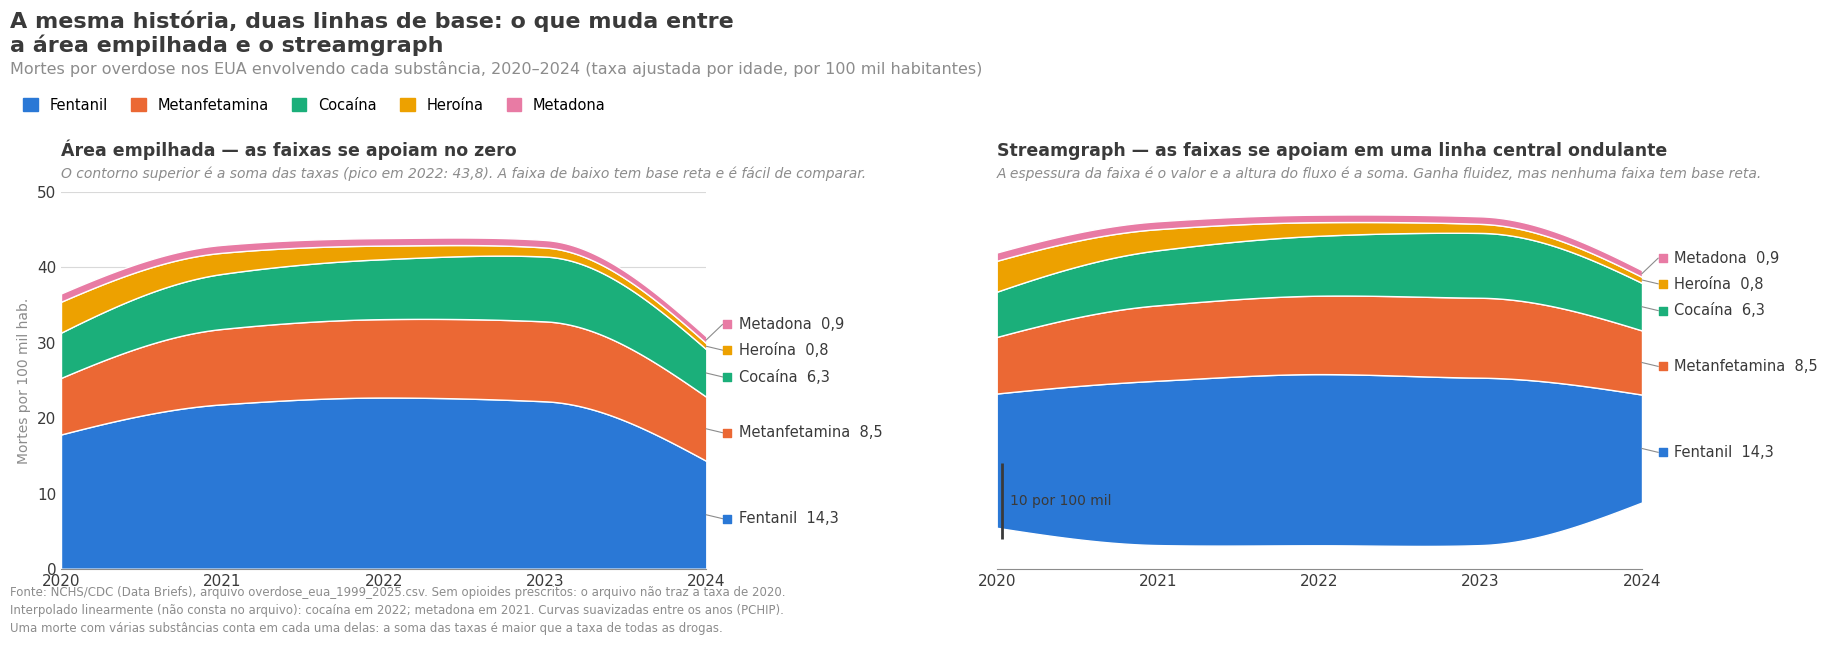

In [4]:
# Área empilhada vs. streamgraph: mesmos dados, duas linhas de base
# Dados: taxa de mortes por overdose envolvendo cada substância (por 100 mil hab., ajustada por idade), EUA.
# Recorte 2020–2024: único período em que o arquivo traz a taxa das cinco substâncias (com 2 lacunas).
import re
from scipy.interpolate import PchipInterpolator

ARQUIVO = "../Data/overdose_eua_1999_2025.csv"
ANOS = list(range(2020, 2025))

# Ordem da pilha (de baixo para cima) e cor fixa de cada substância
CORES = {
    "Fentanil":      "#2a78d6",
    "Metanfetamina": "#eb6834",
    "Cocaína":       "#1baf7a",
    "Heroína":       "#eda100",
    "Metadona":      "#e87ba4",
}
SUBSTANCIAS = list(CORES)

CINZA_ESCURO = "#3A3A3A"   # textos
CINZA_MEDIO  = "#8C8C8C"   # textos secundários
CINZA_CLARO  = "#D9D9D9"   # grade

def br(v, casas=1):
    """Formata número com vírgula decimal."""
    return f"{v:.{casas}f}".replace(".", ",")

def espalhar(pos, gap):
    """Afasta rótulos que ficariam colados (distância mínima 'gap'), mantendo a ordem."""
    pos = np.asarray(pos, float)
    ordem = np.argsort(pos)
    p = pos[ordem].copy()
    for i in range(1, len(p)):
        p[i] = max(p[i], p[i - 1] + gap)
    p += pos[ordem].mean() - p.mean()
    saida = np.empty_like(p)
    saida[ordem] = p
    return saida

# --- Leitura: a taxa está escrita dentro da coluna "descrição" ("... taxa de 22,7 por 100.000 ...")
raw = pd.read_csv(ARQUIVO, sep="\t", encoding="utf-16")
raw["ano"] = pd.to_numeric(raw["ano"], errors="coerce")
raw["substancia"] = raw["causa"].str.split(" (", regex=False).str[0]
raw["taxa"] = (raw["descrição"]
               .str.extract(r"taxa de ([\d,]+) por 100\.000", flags=re.IGNORECASE)[0]
               .str.replace(",", ".", regex=False).astype(float))

sel = raw[raw["ano"].isin(ANOS) & raw["substancia"].isin(SUBSTANCIAS)].dropna(subset=["taxa"])
tab = (sel.pivot(index="ano", columns="substancia", values="taxa")
          .reindex(index=ANOS, columns=SUBSTANCIAS))
lacunas = [(s, int(a)) for s in SUBSTANCIAS for a in ANOS if np.isnan(tab.loc[a, s])]
tab = tab.interpolate(method="index")          # lacunas: interpolação linear entre os anos vizinhos

# Curvas suaves (PCHIP não cria picos que os dados não têm) para as duas versões do gráfico
x = np.linspace(ANOS[0], ANOS[-1], 300)
y = np.array([PchipInterpolator(tab.index, tab[s])(x) for s in SUBSTANCIAS])
total = y.sum(axis=0)
ALTURA = 50                                     # mesma escala vertical nos dois painéis

def base_streamgraph(y):
    """Linha de base "ondulante" (Byron & Wattenberg): mantém o centro do fluxo estável,
    minimizando a oscilação das faixas. É a única diferença em relação à área empilhada."""
    tot = y.sum(axis=0)
    peso_abaixo = (tot - y.cumsum(axis=0) + y / 2) / tot
    peso_abaixo[:, 0] = 0.5
    variacao = np.hstack((y[:, :1], np.diff(y, axis=1)))
    centro = np.cumsum(((peso_abaixo - 0.5) * variacao).sum(axis=0))
    return centro - tot / 2

def empilhar(ax, base):
    """Empilha as faixas a partir de 'base' (zero ou ondulante), com 2 px de folga entre elas."""
    inferior = base.copy()
    for s, faixa in zip(SUBSTANCIAS, y):
        ax.fill_between(x, inferior, inferior + faixa, color=CORES[s],
                        edgecolor="white", linewidth=1)
        inferior = inferior + faixa

base1 = np.zeros_like(x)          # área empilhada: tudo se apoia no zero
base2 = base_streamgraph(y)       # streamgraph: tudo se apoia numa linha central que ondula
centro2 = (base2.min() + (base2 + total).max()) / 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6.5), sharex=True)
empilhar(ax1, base1)
empilhar(ax2, base2)
ax1.set_ylim(0, ALTURA)
ax2.set_ylim(centro2 - ALTURA / 2, centro2 + ALTURA / 2)

# --- Rótulos diretos à direita (a cor sozinha não basta: amarelo, verde e rosa têm pouco contraste)
for ax, base in ((ax1, base1), (ax2, base2)):
    topo = base[-1] + np.cumsum(y[:, -1])
    meio = topo - y[:, -1] / 2
    pos = espalhar(meio, 3.4)
    for s, m, p, v in zip(SUBSTANCIAS, meio, pos, y[:, -1]):
        ax.plot([ANOS[-1], ANOS[-1] + 0.1], [m, p], color=CINZA_MEDIO, lw=0.8, clip_on=False)
        ax.scatter(ANOS[-1] + 0.13, p, marker="s", s=38, color=CORES[s], clip_on=False, zorder=5)
        ax.text(ANOS[-1] + 0.2, p, f"{s}  {br(v)}", va="center", fontsize=10.5, color=CINZA_ESCURO)

# --- Eixos
for ax in (ax1, ax2):
    ax.set_xlim(ANOS[0], ANOS[-1])
    ax.tick_params(length=0, labelsize=11, colors=CINZA_ESCURO)
    for lado in ["top", "right", "left"]:
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(CINZA_MEDIO)
ax2.set_xticks(ANOS)
ax1.set_xticks(ANOS)
ax1.tick_params(labelbottom=True)

ax1.set_axisbelow(True)
ax1.yaxis.grid(True, color=CINZA_CLARO, linewidth=0.8)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax1.set_ylabel("Mortes por 100 mil hab.", color=CINZA_MEDIO, fontsize=10)

# Streamgraph: sem eixo vertical (a posição não tem significado); uma barra de escala ocupa o lugar
ax2.set_yticks([])
xb, yb = ANOS[0] + 0.03, centro2 - ALTURA / 2 + 4
ax2.plot([xb, xb], [yb, yb + 10], color=CINZA_ESCURO, lw=2, solid_capstyle="butt")
ax2.text(xb + 0.05, yb + 5, "10 por 100 mil", va="center", fontsize=10, color=CINZA_ESCURO)

# --- Títulos dos painéis, com uma linha explicando como ler cada um
ano_pico = ANOS[int(np.argmax(tab.sum(axis=1).values))]
paineis = [
    (ax1, "Área empilhada — as faixas se apoiam no zero",
     f"O contorno superior é a soma das taxas (pico em {ano_pico}: {br(tab.loc[ano_pico].sum())}). "
     "A faixa de baixo tem base reta e é fácil de comparar."),
    (ax2, "Streamgraph — as faixas se apoiam em uma linha central ondulante",
     "A espessura da faixa é o valor e a altura do fluxo é a soma. "
     "Ganha fluidez, mas nenhuma faixa tem base reta."),
]
for ax, titulo, leitura in paineis:
    ax.set_title(titulo, loc="left", fontsize=12.5, fontweight="bold", color=CINZA_ESCURO, pad=26)
    ax.text(0, 1.03, leitura, transform=ax.transAxes, fontsize=10, color=CINZA_MEDIO,
            style="italic", va="bottom")

# --- Título geral, legenda e nota
fig.suptitle("A mesma história, duas linhas de base: o que muda entre\n"
             "a área empilhada e o streamgraph",
             x=0.02, ha="left", fontsize=16, fontweight="bold", color=CINZA_ESCURO)
fig.text(0.02, 0.882, "Mortes por overdose nos EUA envolvendo cada substância, 2020–2024 "
         "(taxa ajustada por idade, por 100 mil habitantes)",
         fontsize=11.5, color=CINZA_MEDIO)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in CORES.values()],
           labels=SUBSTANCIAS, ncol=len(SUBSTANCIAS), loc="upper left",
           bbox_to_anchor=(0.02, 0.865), frameon=False, fontsize=10.5,
           handlelength=1, handleheight=1, columnspacing=1.6)

nota_lacunas = "; ".join(f"{s.lower()} em {a}" for s, a in lacunas)
fig.text(0.02, 0.018,
         "Fonte: NCHS/CDC (Data Briefs), arquivo overdose_eua_1999_2025.csv. Sem opioides prescritos: o arquivo não traz a taxa de 2020.\n"
         f"Interpolado linearmente (não consta no arquivo): {nota_lacunas}. Curvas suavizadas entre os anos (PCHIP).\n"
         "Uma morte com várias substâncias conta em cada uma delas: a soma das taxas é maior que a taxa de todas as drogas.",
         fontsize=8.5, color=CINZA_MEDIO, va="bottom", linespacing=1.5)

fig.subplots_adjust(top=0.70, bottom=0.12, left=0.05, right=0.98, wspace=0.45)
# fig.savefig("area_empilhada_vs_streamgraph.png", dpi=200, bbox_inches="tight")
plt.show()

Os pesquisadores estão cientes de quão incomum é a aparência de um *streamgraph* e de como ele pode ser mais difícil de compreender para os leitores. Ao analisar um *streamgraph* publicado pelo *New York Times* em 2008, pesquisadores observaram que "suspeitam que algumas das qualidades esteticamente agradáveis ​​— ou, pelo menos, cativantes — possam entrar em conflito com a necessidade de legibilidade. O fato de o gráfico do *New York Times* não se parecer com um gráfico estatístico convencional pode muito bem ser parte de seu apelo". Assim, embora esse tipo de gráfico — ou qualquer gráfico de visual incomum — possa inicialmente confundir ou deixar os leitores perplexos, eles podem acabar achando as formas, as cores e outros atributos mais interessantes e envolventes. Tudo depende do seu público.

Na página seguinte, você pode ver um exemplo mais recente de um *streamgraph*. Essa visualização foi publicada pelo *Hindustan Times* em 2016 e mostra a quantidade e o tipo das mais altas condecorações civis concedidas pelo governo indiano. Outros *streamgraphs* na matéria original apresentavam detalhamentos por estado, nacionalidade, gênero e área de atuação.

## GRÁFICO DE HORIZONTE

Um gráfico de horizonte é um gráfico de área dividido em intervalos horizontais iguais e comprimido em faixas individuais, o que torna o gráfico mais compacto e semelhante a um mapa de calor (página 112). O gráfico de horizonte é subdividido em faixas, nas quais os valores positivos são comprimidos e os valores negativos são invertidos para cima do eixo horizontal. Múltiplos gráficos de horizonte — forma como são tipicamente organizados — permitem condensar um conjunto de dados denso em uma única visualização. Eles são especialmente úteis ao visualizar dados de séries temporais com valores tão próximos que, em um gráfico de linha, por exemplo, os pontos de dados acabariam sobrepostos. Alinhar os gráficos dessa maneira permite apresentar os dados em um espaço mais compacto do que seria possível com uma série de gráficos de área.

A cor é o atributo mais importante em um gráfico de horizonte. Cores mais escuras representam valores maiores, e cores mais claras, valores menores. Assim como ocorre com os *sparklines* e, até certo ponto, com os mapas de calor, o objetivo do gráfico de horizonte não é necessariamente permitir que os leitores identifiquem valores específicos, mas sim visualizar facilmente tendências gerais e identificar valores extremos.

Este gráfico de horizonte utiliza os mesmos dados que temos empregado para analisar as variações na porcentagem do PIB destinada à saúde pública. Um gráfico de área é criado para cada país, dividido e compactado, e, em seguida, todos são organizados em linhas. Observe a grande quantidade de dados concentrada em uma única visualização (dez países e quinze anos) e — lembrando-se da importância do processamento pré-atentivo — note como o seu olhar é atraído pelas cores mais claras e mais escuras.

Usarei a série referente à Suécia para demonstrar como o gráfico de horizonte é construído. A variação nos gastos com saúde pública na Suécia (o terceiro país de baixo para cima neste gráfico de horizonte) é apresentada na página seguinte como um gráfico de área, dividido em intervalos iguais (de 0,5 ponto percentual cada). Valores mais altos são representados por tons mais escuros, enquanto valores negativos e positivos utilizam cores distintas; os valores negativos são invertidos para ficarem acima do eixo horizontal, e todos são comprimidos no primeiro intervalo ou faixa.

A cor é o elemento-chave aqui. A mesma visualização apresentada como uma série de gráficos de linhas não causa o mesmo impacto. O olhar percorre toda a visualização em busca de tendências importantes, mas nenhuma região específica da imagem atrai nossa atenção. Isso poderia ser alterado adicionando-se cores às diferentes linhas para destacar valores extremos; no entanto, o gráfico de horizonte consegue direcionar o olhar de forma muito mais eficaz ao destacar valores por meio de cores.

## GRÁFICOS DE GANTT

Outra maneira de demonstrar mudanças ao longo do tempo é utilizar linhas ou barras horizontais para indicar a duração de diferentes valores ou ações. Os gráficos de Gantt são frequentemente empregados para acompanhar cronogramas — por exemplo, para monitorar as diversas fases de um projeto ou orçamento. Criados por Henry Laurence Gantt, um engenheiro que atuou na virada do século XX, esses gráficos foram utilizados inicialmente por encarregados e supervisores de produção para acompanhar cronogramas produtivos.

Este gráfico de Gantt mostra os turnos da equipe em uma cafeteria ao longo do dia, indicando intervalos com espaços em branco, pausas para almoço com espaços cinzas e outros períodos de ausência da loja com faixas hachuradas.

Os gráficos de Gantt podem ser ampliados modificando-se a largura das barras para representar outra variável. Por exemplo, este gráfico de Gantt modifica o gráfico hipotético anterior para ajustar as larguras de acordo com a remuneração de cada funcionário.

Joseph Priestley, filósofo, químico e educador do século XVIII, publicou *A Chart of Biography* em 1765, apresentando a duração da vida de aproximadamente dois mil estadistas, poetas, artistas e outras personalidades notáveis ​​que viveram entre 1200 a.C. e meados do século XVIII. Frequentemente chamada de linha do tempo, a tabela de Priestley assemelha-se mais a um gráfico de Gantt devido ao uso de barras ou linhas horizontais e à indicação precisa de inícios (nascimentos) e términos (falecimentos).

## FLUXOGRAMAS E LINHAS DO TEMPO

Fluxogramas e linhas do tempo são dois exemplos de uma variedade de recursos visuais que podem exibir mudanças ao longo do tempo ou diferentes tipos de processos, sequências ou hierarquias. Essa categoria de gráficos e diagramas pode estar diretamente vinculada a dados ou ter um caráter menos quantitativo e mais ilustrativo, servindo para demonstrar diferentes estruturas ou processos. No PowerPoint, por exemplo, você pode explorar o menu "SmartArt" para encontrar uma ampla seleção de layouts.

Uma linha do tempo mostra quando determinados eventos ocorrem. Ela pode ser simples, indicando eventos com uma linha, ícone ou marcador, ou mais elaborada, incluindo anotações, imagens ou até mesmo gráficos. Embora as linhas do tempo horizontais sejam comuns, elas também podem ser verticais ou apresentar diversos outros formatos. Esta linha do tempo, baseada em um trabalho que realizei no *Congressional Budget Office* (Escritório de Orçamento do Congresso), mostra marcos importantes e dados relativos ao *Supplemental Nutrition Assistance Program* (SNAP, anteriormente conhecido como programa de *food stamps* ou vales-alimentação). O texto nas caixas cinzas à direita fornece detalhes sobre legislações específicas ou alterações no programa, enquanto as informações à esquerda apresentam mudanças nos gastos, no número de participantes do programa e na proporção desses participantes em relação à população total.

Os fluxogramas são um pouco diferentes. Eles não estão necessariamente vinculados ao tempo — em termos de dias, meses ou anos —, mas sim mapeiam um processo, frequentemente passo a passo. Os fluxogramas facilitam a compreensão dos caminhos de um processo por parte dos leitores, evitando a necessidade de ler longos trechos de texto ou de navegar por tabelas complexas. O fluxograma na página seguinte ilustra o processo pelo qual as pessoas podem solicitar e receber benefícios por meio do programa de Seguro por Invalidez da Previdência Social dos EUA (DI). Os solicitantes iniciam o processo na etapa denominada "Serviços de Determinação de Invalidez" (Disability Determination Services). Se a solicitação for aprovada, eles são admitidos no programa; caso contrário, podem recorrer da decisão ou desistir totalmente do processo. O programa foi estruturado de modo a permitir que os solicitantes recorram de uma negativa em cada uma das etapas.

As formas em um fluxograma podem ter significados distintos; portanto, podemos utilizá-las estrategicamente para indicar diferentes atributos do sistema. Por exemplo, em um fluxograma composto por retângulos, outras formas podem representar pontos de estrangulamento ou de decisão, enquanto retângulos de cantos arredondados podem sinalizar o início ou o fim de um processo. O uso de cores diferentes pode ajudar os leitores a compreender e distinguir as diversas partes do diagrama.

Se, por exemplo, quiséssemos destacar as diferentes partes do sistema de aplicação de DI, poderíamos utilizar cores e formas distintas, como na versão central. Em um fluxograma, os rótulos podem ser posicionados ao lado das linhas ou dentro das caixas, mas devem ter tamanho e contraste de cor suficientes para permitir uma leitura fácil. Poderíamos ir além e ajustar a escala de elementos do fluxograma com base em determinados valores de dados; na versão à direita, por exemplo, as ramificações têm suas dimensões ajustadas de acordo com as respectivas proporções em cada etapa, de forma semelhante a um diagrama de Sankey (página 126).

Incluo o fluxograma no capítulo sobre tempo porque esses processos frequentemente ocorrem ao longo do tempo, um após o outro. Mas nem sempre é assim. Um organograma, por exemplo, é um tipo de fluxograma que mostra a hierarquia ou a estrutura de gestão de uma organização e como o trabalho flui de cima para baixo. Veremos mais exemplos de organogramas no Capítulo 8.

Assim como vimos no caso do gráfico de linhas com muitas séries, a questão não é a quantidade de conteúdo inserida no gráfico, mas sim o que atende às necessidades do leitor. O fluxograma da página 174, por exemplo, foi elaborado em 2010 pela equipe republicana do Comitê Econômico Conjunto em resposta à proposta do *Affordable Care Act* (Lei de Assistência Acessível) do presidente Obama. O objetivo implícito desse fluxograma é demonstrar a complexidade da proposta (e da assistência à saúde, de modo geral) nos Estados Unidos. Nesse sentido, o gráfico cumpre bem o seu papel!